In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X, y = load_wine(return_X_y=True)

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))


Dataset shape: (178, 13)
Number of classes: 3


In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (124, 13)
Validation: (27, 13)
Test: (27, 13)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [17]:
configs = [
    ((50,), 'relu', 0.001),
    ((100,), 'relu', 0.001),
    ((50, 50), 'relu', 0.001),
    ((100, 50), 'relu', 0.001),
    ((50,), 'tanh', 0.001),
    ((100,), 'tanh', 0.001)
]

results = []

for hidden_layers, activation, lr in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, mlp.predict(X_train_scaled))
    val_acc   = accuracy_score(y_val, mlp.predict(X_val_scaled))
    
    results.append([hidden_layers, activation, lr, train_acc, val_acc])


In [18]:
results_df = pd.DataFrame(
    results,
    columns=["Hidden Layers", "Activation", "LR", "Train Accuracy", "Val Accuracy"]
)

results_df.sort_values("Val Accuracy", ascending=False)


,Hidden Layers,Activation,LR,Train Accuracy,Val Accuracy
0,"(50,)",relu,0.001,1.0,1.000000
1,"(100,)",relu,0.001,1.0,1.000000
2,"(50, 50)",relu,0.001,1.0,1.000000
3,"(100, 50)",relu,0.001,1.0,1.000000
4,"(50,)",tanh,0.001,1.0,1.000000
5,"(100,)",tanh,0.001,1.0,0.962963


In [19]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)

# Accuracy
train_acc = accuracy_score(y_train, best_mlp.predict(X_train_scaled))
val_acc   = accuracy_score(y_val, best_mlp.predict(X_val_scaled))
test_acc  = accuracy_score(y_test, best_mlp.predict(X_test_scaled))

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 1.0


In [20]:
print("Classification Report (Test Set):")
print(classification_report(y_test, best_mlp.predict(X_test_scaled)))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



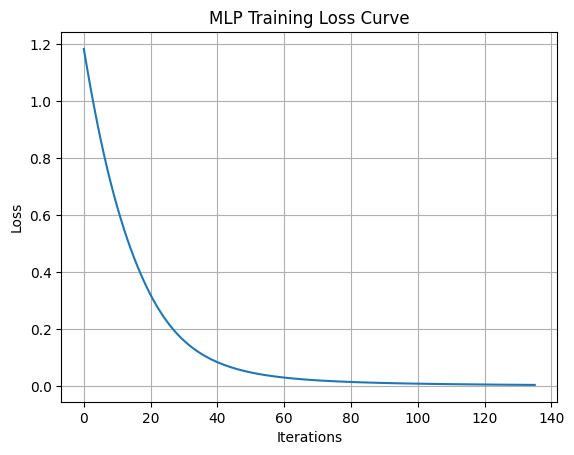

In [11]:
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.grid()
plt.show()
